# Beyond A/B Testing

**Philosophy:** Deliberately short. This note is a decision framework and concept map — not a full implementation guide. When you can't randomize, use this to pick the right method. Full implementations live in `causal_ml/`. The one addition with code: the **intuition gallery** — the four pictures you should be able to draw on a whiteboard.

---

## Decision Table

| If you need to... | Go to |
| :--- | :--- |
| Understand why A/B isn't always possible | §1 — Why You Can't Always Randomize |
| Pick the right observational method | §2 — Decision Framework |
| Draw each method's identifying picture | §2.5 — Intuition Gallery |
| Compare methods at a glance | §3 — Method Comparison Table |
| Structure an interview answer + worked cases | §4 — Interview Playbook |

---
## §1 — Why You Can't Always Randomize

Randomized A/B testing is the gold standard — but it requires conditions that are often not met in practice.

| Reason | Example | Consequence |
| :--- | :--- | :--- |
| **Ethical constraints** | Can't randomly deny medical treatment or financial credit | Must use observational data |
| **One-sided markets** | Pricing or fee changes affect all users — can't split | Geo or time-based design needed |
| **Small population** | B2B product with 200 enterprise users | Insufficient power for standard A/B |
| **Historical data only** | Evaluating a past policy that already ran | No future randomization possible |
| **Platform-level changes** | Infrastructure change — can't toggle per user | Switchback or pre/post design |
| **Network effects** | Social feature — users interact, contaminating groups | Cluster randomization or observational |
| **Long time horizon** | Measuring 1-year LTV impact | Can't wait; use proxy or observational |

**The core problem:**
Without randomization, the treated and untreated groups differ systematically before treatment. Naive comparison mixes the treatment effect with pre-existing differences (confounding). Every observational method is an attempt to adjust for this — with different assumptions, data requirements, and validity.

---
## §2 — Decision Framework

```
Can you randomly assign treatment?
│
├── YES, at the user level ───────────────────────────────────────────────────
│   └── A/B Test (see Exp_Design.ipynb, Exp_Analysis.ipynb)
│
├── YES, but not per user (interference / platform-wide / supply-demand) ─────
│   │
│   ├── Isolated groups exist (cities, regions, cohorts)?
│   │   └── Geo / Cluster experiment
│   │       Randomize clusters; analyze with cluster-robust SEs (Design §3–4).
│   │       Few clusters? → pair with synthetic control for the analysis.
│   │
│   └── Treatment can be toggled over time (marketplace pricing, dispatch algo)?
│       └── Switchback experiment
│           Alternate treatment ON/OFF in time blocks, randomized order.
│           Assumption: no/limited carryover between periods
│           Design: block length > carryover horizon; discard burn-in windows
│           Limitation: temporal correlation → fewer effective observations
│
└── NO — choose based on what data structure you have:
    │
    ├── Is there a sharp cutoff / threshold that determines treatment?
    │   (score above 700 gets a loan, age ≥ 65 gets a benefit)
    │   └── Regression Discontinuity (RD)
    │       Assumption: units just above/below the cutoff are comparable
    │       Strength: near-experimental validity near the cutoff
    │       Limitation: only identifies the effect at the cutoff, not population ATE
    │
    ├── Do you have pre/post data AND a control group that was never treated?
    │   (policy changed in some states but not others, some stores got a renovation)
    │   │
    │   ├── MANY control units, ONE (or few) treated → also consider:
    │   │   └── Synthetic Control
    │   │       Build a weighted combo of control units ("donor pool") that
    │   │       matches the treated unit's PRE-period trajectory; the post-period
    │   │       gap between actual and synthetic = the effect
    │   │       Assumption: pre-period fit is good; no donor was also treated/shocked
    │   │       Strength: works with a single treated unit (one country, one city)
    │   │       Limitation: inference is awkward (placebo/permutation tests)
    │   │
    │   └── Several treated + several control units →
    │       └── Difference-in-Differences (DiD)
    │           Assumption: parallel trends — treated and control would have
    │                       followed the same trend without treatment
    │           Strength: controls for time-invariant confounders
    │           Limitation: parallel trends is untestable; fails if groups
    │                       diverge pre-treatment
    │
    ├── Do you have a variable that affects treatment but not outcome directly?
    │   (lottery assignment, distance to a facility, policy eligibility cutoff)
    │   └── Instrumental Variables (IV)
    │       Assumption: instrument is relevant (correlated with treatment) and
    │                   exogenous (uncorrelated with outcome except through treatment)
    │       Strength: handles unmeasured confounders
    │       Limitation: valid instruments are rare; identifies LATE, not ATE
    │
    ├── Do you have rich pre-treatment covariates and assume no unmeasured confounders?
    │   (observational data with demographics, history, behavior)
    │   └── Matching / Propensity Score Methods (PSM, IPW, Doubly Robust)
    │       Assumption: unconfoundedness — no unmeasured confounders
    │                   (selection on observables)
    │       Strength: flexible, works on any observational data
    │       Limitation: cannot handle unmeasured confounders
    │
    └── Do you want individual-level treatment effects, not just average?
        └── CATE / Uplift Modeling (causal forests, X-learner, T-learner)
            Assumption: unconfoundedness (same as matching)
            Strength: heterogeneous treatment effects by subgroup
            Limitation: harder to validate; assumes rich covariate data
```

---
## §2.5 — Intuition Gallery

The four pictures interviewers expect you to sketch. Each panel below uses *illustrative* simulated data — the picture **is** the identification argument. (Fitting code lives in `causal_ml/`.)

- **DiD:** the effect is the gap between the treated line and where it *would have gone* (control's trend, dashed).
- **RD:** the effect is the *jump* in the outcome exactly at the cutoff.
- **Synthetic control:** the effect is the divergence between the treated unit and its synthetic twin after treatment.
- **Switchback:** the effect is the average ON−OFF difference across randomized time blocks.

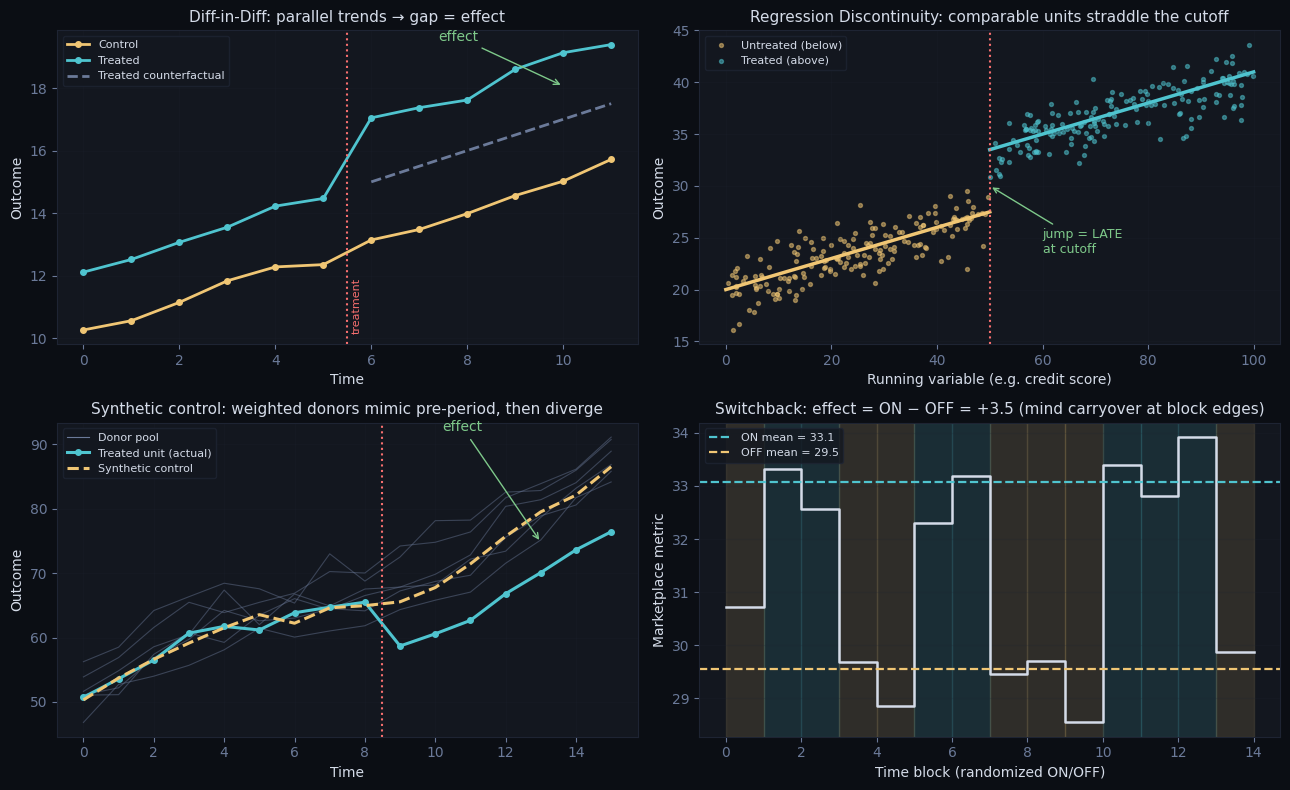

In [1]:
import numpy as np
import matplotlib.pyplot as plt

BG, PANEL, GRID = '#0b0e14', '#13171f', '#1e2433'
TXT, MUT = '#d4dbe8', '#6b7a99'
CYAN, AMBER, GREEN, RED = '#4fc4cf', '#f0c674', '#7ec98a', '#f76f6f'

np.random.seed(0)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.patch.set_facecolor(BG)
for ax in axes.ravel():
    ax.set_facecolor(PANEL); ax.tick_params(colors=MUT)
    ax.spines[:].set_color(GRID); ax.grid(True, alpha=0.2, color=GRID)
def lab(ax, x, y, t):
    ax.set_xlabel(x, color=TXT); ax.set_ylabel(y, color=TXT)
    ax.set_title(t, color=TXT, fontsize=11)
def leg(ax): ax.legend(labelcolor=TXT, facecolor=PANEL, edgecolor=GRID, fontsize=8)

# (1) Difference-in-Differences
t = np.arange(0, 12); T0 = 6
ctrl_l = 10 + 0.5*t + np.random.normal(0, .15, 12)
trt_l  = 12 + 0.5*t + np.random.normal(0, .15, 12) + np.where(t >= T0, 2.0, 0)
cf     = 12 + 0.5*t
ax = axes[0, 0]
ax.plot(t, ctrl_l, 'o-', color=AMBER, lw=2, ms=4, label='Control')
ax.plot(t, trt_l,  'o-', color=CYAN,  lw=2, ms=4, label='Treated')
ax.plot(t[T0:], cf[T0:], '--', color=MUT, lw=2, label='Treated counterfactual')
ax.axvline(T0 - .5, color=RED, ls=':', lw=1.5)
ax.annotate('effect', xy=(10, (trt_l[10]+cf[10])/2), color=GREEN, fontsize=10,
            xytext=(7.4, 19.5), arrowprops=dict(arrowstyle='->', color=GREEN))
ax.text(T0 - .4, 10.2, 'treatment', color=RED, fontsize=8, rotation=90)
lab(ax, 'Time', 'Outcome', 'Diff-in-Diff: parallel trends → gap = effect')
leg(ax)

# (2) Regression Discontinuity
x = np.random.uniform(0, 100, 350); cut = 50
y = 20 + 0.15*x + np.where(x >= cut, 6.0, 0) + np.random.normal(0, 1.6, 350)
ax = axes[0, 1]
ax.scatter(x[x < cut], y[x < cut], s=8, alpha=.5, color=AMBER, label='Untreated (below)')
ax.scatter(x[x >= cut], y[x >= cut], s=8, alpha=.5, color=CYAN, label='Treated (above)')
xs = np.linspace(0, cut, 20);  ax.plot(xs, 20 + .15*xs, color=AMBER, lw=2.5)
xs = np.linspace(cut, 100, 20); ax.plot(xs, 26 + .15*xs, color=CYAN, lw=2.5)
ax.axvline(cut, color=RED, ls=':', lw=1.5)
ax.annotate('jump = LATE\nat cutoff', xy=(cut, 30), xytext=(60, 23.5), color=GREEN,
            fontsize=9, arrowprops=dict(arrowstyle='->', color=GREEN))
lab(ax, 'Running variable (e.g. credit score)', 'Outcome',
    'Regression Discontinuity: comparable units straddle the cutoff')
leg(ax)

# (3) Synthetic Control
t = np.arange(0, 16); T0 = 9
base = 50 + 2.2*t + 3*np.sin(t/2)
actual = base + np.random.normal(0, .7, 16) + np.where(t >= T0, -8.5, 0)
synth  = base + np.random.normal(0, .7, 16)
ax = axes[1, 0]
for _ in range(6):                                          # donor pool
    ax.plot(t, base + np.random.normal(0, 4) + np.random.normal(0, 1.4, 16),
            color=MUT, lw=.8, alpha=.45)
ax.plot([], [], color=MUT, lw=.8, label='Donor pool')
ax.plot(t, actual, 'o-', color=CYAN, lw=2.2, ms=4, label='Treated unit (actual)')
ax.plot(t, synth, '--', color=AMBER, lw=2.2, label='Synthetic control')
ax.axvline(T0 - .5, color=RED, ls=':', lw=1.5)
ax.annotate('effect', xy=(13, (actual[13]+synth[13])/2), xytext=(10.2, 92),
            color=GREEN, fontsize=10, arrowprops=dict(arrowstyle='->', color=GREEN))
lab(ax, 'Time', 'Outcome', 'Synthetic control: weighted donors mimic pre-period, '
                           'then diverge')
leg(ax)

# (4) Switchback
n_blocks = 14
on = np.random.permutation(np.tile([0, 1], n_blocks // 2))
y_blk = 30 + 3.0*on + np.random.normal(0, .9, n_blocks)
ax = axes[1, 1]
for i, o in enumerate(on):
    ax.axvspan(i, i + 1, color=CYAN if o else AMBER, alpha=.13)
ax.step(np.arange(n_blocks + 1), np.r_[y_blk, y_blk[-1]], where='post',
        color=TXT, lw=1.8)
on_mean, off_mean = y_blk[on == 1].mean(), y_blk[on == 0].mean()
ax.axhline(on_mean,  color=CYAN,  ls='--', lw=1.6, label=f'ON mean = {on_mean:.1f}')
ax.axhline(off_mean, color=AMBER, ls='--', lw=1.6, label=f'OFF mean = {off_mean:.1f}')
lab(ax, 'Time block (randomized ON/OFF)', 'Marketplace metric',
    f'Switchback: effect = ON − OFF = {on_mean - off_mean:+.1f} '
    '(mind carryover at block edges)')
leg(ax)

plt.tight_layout(); plt.show()

---
## §3 — Method Comparison Table

| Method | Key assumption | Data required | Identifies | Handles unmeasured confounders? | Go deeper |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **A/B Test** | Random assignment (+ SUTVA) | RCT data | ATE | ✅ Yes — by design | `Exp_Design`, `Exp_Analysis` |
| **Geo / Cluster experiment** | Isolated clusters | Cluster-level randomization | ATE (cluster-level) | ✅ Yes — by design | `Exp_Design §3–4` |
| **Switchback** | No / limited carryover | Time-block randomization | ATE (temporal) | ✅ Yes — by design | `causal_ml/` |
| **Diff-in-Diff** | Parallel trends | Panel data, pre+post, control group | ATT | ✅ For time-invariant only | `causal_ml/` |
| **Synthetic Control** | Good pre-period fit, clean donors | Long pre-period, donor pool, 1–few treated units | ATT (treated unit) | ✅ If reflected in pre-period fit | `causal_ml/` |
| **Regression Discontinuity** | Continuity at cutoff | Running variable + cutoff | LATE (at cutoff) | ✅ Near cutoff | `causal_ml/` |
| **Instrumental Variables** | Valid instrument | Instrument + treatment + outcome | LATE (compliers) | ✅ Yes | `causal_ml/` |
| **Matching / PSM / IPW** | Unconfoundedness | Rich covariates | ATE / ATT | ❌ No | `causal_ml/` |
| **CATE / Uplift** | Unconfoundedness | Rich covariates + many observations | CATE (individual) | ❌ No | `causal_ml/` |

**ATE** = Average Treatment Effect (population average)
**ATT** = Average Treatment Effect on the Treated
**LATE** = Local Average Treatment Effect (only for a subset — near cutoff or compliers)
**CATE** = Conditional Average Treatment Effect (individual-level, conditional on covariates)

---
## §4 — Interview Playbook

When asked *"how would you measure the effect of X without an A/B test?"*, structure your answer around:

```
1. Why can't we randomize?         Identify the specific constraint.

2. What's the causal question?     What is the treatment? What is the outcome?
                                   What would we see in the counterfactual world?

3. What data do we have?           Panel? Cross-section? Pre/post? Instrument?
                                   One treated unit or many?

4. What's the key assumption?      Name it explicitly — parallel trends, pre-period fit,
                                   no carryover, unconfoundedness, valid instrument.

5. How would we validate it?       Pre-trend test for DiD. Placebo (in-time / in-donor)
                                   tests for synthetic control. Density + placebo tests
                                   for RD. First-stage F-stat for IV. Balance check for
                                   matching. Vary block length for switchback.

6. What does it identify?          ATE? ATT? LATE? Be precise — it affects generalizability.
```

### Worked Case 1 — "Measure the impact of a delivery-fee change" (one-sided market)

1. **Why no A/B:** fees shape the *shared* supply-demand equilibrium — treating half the buyers changes couriers' behavior for everyone (interference / SUTVA violation).
2. **Question:** effect of new fee on orders, revenue/order, courier utilization.
3. **Data/design options:** we control the lever → **switchback** (alternate fee by randomized time blocks within each city) or **geo experiment** (randomize cities; if few cities, analyze with synthetic-control-style weighting).
4. **Key assumption:** switchback — carryover shorter than the block (users don't time orders around fee flips); geo — clusters isolated, comparable.
5. **Validation:** vary block length and check estimate stability; discard burn-in windows at block edges; for geo, check pre-period balance across city groups.
6. **Identifies:** time-averaged ATE at the market level; note heterogeneity by daypart is exploratory.

### Worked Case 2 — "A tax on sugary drinks launched in one city last year — did it work?" (historical, one treated unit)

1. **Why no A/B:** the policy already happened, citywide, once.
2. **Question:** effect on consumption in the treated city vs its counterfactual.
3. **Data:** monthly consumption for the city + many untreated cities (donor pool), several pre-years → **synthetic control**, with **DiD** as the simpler benchmark if several comparable cities moved together.
4. **Key assumption:** donors weighted to match the treated city's *pre-period* path would have kept matching absent the tax; no donor had its own shock.
5. **Validation:** pre-period fit quality; in-time placebo (fake earlier treatment date → should show no effect); in-donor placebos (apply method to each donor → treated city's gap should be extreme in the permutation distribution). For DiD: pre-trend plot.
6. **Identifies:** ATT for that city — be careful generalizing to other cities.

### Worked Case 3 — "Does getting a loan improve customer LTV?" (ethical constraint + selection)

1. **Why no A/B:** can't randomly deny credit; approved vs rejected differ massively (selection on creditworthiness).
2. **Question:** effect of loan approval on 2-year LTV.
3. **Data:** approval is driven by a score with a **sharp cutoff** → **Regression Discontinuity** on applicants near the threshold. (If approvals were partly randomized by an eligibility expansion or lottery — that's an **IV**.)
4. **Key assumption:** continuity — applicants just below and just above the cutoff are exchangeable; no precise manipulation of the score.
5. **Validation:** McCrary density test (no bunching at the cutoff); covariate smoothness across the cutoff; placebo cutoffs; bandwidth sensitivity.
6. **Identifies:** LATE *at the cutoff* — marginal applicants, not your best or worst customers. Say this unprompted.

**Common mistakes:**
- Jumping to PSM without acknowledging the unconfoundedness assumption — interviewers always probe this
- Claiming DiD identifies ATE when it only identifies ATT (effect on the treated group, not the general population)
- Using synthetic control with a poor pre-period fit, or with donors that experienced their own shocks — the method's validity *is* the pre-period fit
- Ignoring carryover in switchbacks — block edges are contaminated; design block length around the carryover horizon and drop burn-in
- Forgetting to validate the key assumption — every observational method has one critical assumption that must be tested or at least discussed
- Treating observational estimates with the same confidence as A/B results — always caveat with the assumption and its limitations